## Example analysis workflow — from raw data to fitted, colour-resolved puncta (FRET, Holliday junctions, ZWO camera)

Worked example of the full single-molecule analysis pipeline on a real acquisition
(**ZWO** Bayer camera, not Ximea -- `camera="zwo"` throughout below), rather than
simulated data: a FRET Holliday-junction sample
(`ZWO_HJs/50mM_MgCl_20pMHJ_515LP650200BP_100perc515_2`). Unlike the single-position
PAINT notebooks (Nile Red/NR4A), this acquisition used a MicroManager multi-position
stage -- a 5x5 grid of 25 positions (`Pos-{{row}}-{{col}}`), each its own separate
`.ome.tif` + metadata + fitted `.h5` file set, so a **`POSITION` selector** (same
convention as `FigureSI_ExampleAnalysisWorkflow_QDots.ipynb`) picks which one this
notebook analyses. Each position's acquisition (2500 frames, ~2.3 GB) fits within
MicroManager's single-file 4 GB limit, so -- unlike the PAINT notebooks -- there's no
multi-file splitting to handle here; each frame is read directly from the one file.

Fitting has already been run end-to-end and saved to `..._MMStack_{{POSITION}}.h5`, so
this notebook loads those existing fit results directly rather than re-running spot
detection (a separate `..._colourchangepoint.h5` also exists per position, from FRET
change-point/step analysis on top of these fits -- not used here, since Figure 2 shows
raw single-frame PSF fits, not the change-point-processed traces).

**Figure 2**: `N_PUNCTA` example puncta (user-controllable, `ROI_SIZE` pixels each), one
per column, rows = raw punctum / per-pixel fitting weights / reconstructed PSF fit (red X
= recovered position) / fit residual / recovered spectral signature (per-channel
amplitude fraction). No narrow `A_R` band restriction here (unlike the two-fixed-dye
SuperRes template) -- candidates are selected purely on fit-quality criteria
(chi_sqr/photons/background_photons), tuned to this dataset's own distribution.

Figure 2 does not re-fit anything: it picks `N_PUNCTA` individual single-frame
localisations directly from the loaded fits, then re-renders everything downstream
straight from the raw data -- the same building blocks the production pipeline uses
(`SR_Functions.SuperRes_Functions`, `ImageAnalysisFunctions.fit_puncta_parallel_method`
with `FittingStrategy.STANDARD_DATA`).

In [1]:
import logging
logging.basicConfig(level=logging.WARNING, format='%(name)s — %(levelname)s — %(message)s')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import re
import types
import tifffile
from pathlib import Path

from pyS3M import IOFunctions, SR_Functions, MaskFunctions, sCMOSFunctions, PlottingBase
# Bare import (not `from src.ImageAnalysisFunctions import ...`) -- see claude/TODO.md's
# note on the dual-import module-identity trap: SR_Functions bare-imports
# ImageAnalysisFunctions internally, so importing it the same way here keeps
# FittingStrategy/FittingConstants consistent with what SR_Functions uses.
from pyS3M.ImageAnalysisFunctions import FittingStrategy, Image_Analysis_Functions
import pyS3M.gaussoptfuncs as gaussoptfuncs
import pyS3M.render as render

IO       = IOFunctions.IO_Functions()
# camera="zwo" alone is enough here (unlike SAureus_Analysis_ZWO_RawAnalysis.ipynb's
# fit_imaging_data path): we only ever read SupRes_F.mosaic_unit/SupRes_F.helper below,
# never its internal mask_functions/spot_detection_functions sub-instances (the ones that
# don't inherit camera="zwo" automatically -- see that notebook's own note), so there's
# no dual-camera-config trap to worry about for what this notebook actually uses.
SupRes_F = SR_Functions.SuperRes_Functions(camera="zwo")
M_F      = MaskFunctions.Mask_Functions(camera="zwo")
sCMOS    = sCMOSFunctions.sCMOS_Functions()
IAF      = Image_Analysis_Functions()
plotter  = PlottingBase.PublicationPlotter()

FIGURE_DIR = Path('/home/jbeckwith/Documents/Chemistry/Lee/Papers/Multicolour/SI/ExampleAnalysisWorkflow_FRET_ZWOHJs/')
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

pyS3M.Constants — INFO — Logging to file: /home/jbeckwith/Documents/Chemistry/Lee/Code/Python/pyS3M/logs/pyS3M.Constants_20260801_124049.log


In [13]:
# ── User-controllable parameters ─────────────────────────────────────────────
DATA_DIR = "/media/jbeckwith/Ezra Seagat/ZWO_HJs/50mM_MgCl_20pMHJ_515LP650200BP_100perc515_2/"
POSITION = "Pos-0-0"   # which MicroManager multi-position stage position to use

ROI_SIZE       = 12   # ROI (pixels) cropped around each punctum for Figure 2
N_PUNCTA       = 6    # number of example puncta to show in Figure 2
SELECTION_SEED = 8    # random seed controlling which fitted puncta are shown

# Figure 2 candidate-selection quality filter, tuned to THIS dataset's own
# chi_sqr/photons/background_photons distribution (noticeably different from the
# Ximea PAINT datasets -- higher chi_sqr, lower photons/background, consistent
# with the ZWO camera + FRET sample rather than a data-quality problem). No A_R
# band restriction: candidates are selected purely on fit-quality criteria.
CHI_SQR_MAX          = 3.5
PHOTON_BG_MIN        = 12.0
PHOTON_BG_MAX         = 25.0
MIN_PHOTONS_OVERVIEW = 500
MAX_PHOTONS_OVERVIEW = 1300

# base_prefix derived from an actual metadata file present, rather than assumed to
# match DATA_DIR's own folder name. Also lists every position actually available,
# so POSITION above can be picked from real options rather than guessed.
_position_re = re.compile(r'_MMStack_(Pos-\d+-\d+)_metadata\.txt$')
_meta_candidates = sorted(Path(DATA_DIR).glob('*_MMStack_Pos-*_metadata.txt'))
if not _meta_candidates:
    raise FileNotFoundError(f'No *_MMStack_Pos-*_metadata.txt found in {DATA_DIR}')
available_positions = sorted({
    m.group(1) for f in _meta_candidates if (m := _position_re.search(f.name))
})
base_prefix = _meta_candidates[0].name.split('_MMStack_')[0]
print(f'base_prefix: {base_prefix}')
print(f'{len(available_positions)} position(s) available: {available_positions}')
if POSITION not in available_positions:
    raise ValueError(f'POSITION={POSITION!r} not found; choose one of {available_positions}')

FILE    = os.path.join(DATA_DIR, f"{base_prefix}_MMStack_{POSITION}.ome.tif")
META    = os.path.join(DATA_DIR, f"{base_prefix}_MMStack_{POSITION}_metadata.txt")
H5_FILE = os.path.join(DATA_DIR, f"{base_prefix}_MMStack_{POSITION}.h5")
print(f'Raw file: {FILE}')
print(f'Localisations file: {H5_FILE}')

base_prefix: 50mM_MgCl_20pMHJ_515LP650200BP_100perc515_2
25 position(s) available: ['Pos-0-0', 'Pos-0-1', 'Pos-0-2', 'Pos-0-3', 'Pos-0-4', 'Pos-1-0', 'Pos-1-1', 'Pos-1-2', 'Pos-1-3', 'Pos-1-4', 'Pos-2-0', 'Pos-2-1', 'Pos-2-2', 'Pos-2-3', 'Pos-2-4', 'Pos-3-0', 'Pos-3-1', 'Pos-3-2', 'Pos-3-3', 'Pos-3-4', 'Pos-4-0', 'Pos-4-1', 'Pos-4-2', 'Pos-4-3', 'Pos-4-4']
Raw file: /media/jbeckwith/Ezra Seagat/ZWO_HJs/50mM_MgCl_20pMHJ_515LP650200BP_100perc515_2/50mM_MgCl_20pMHJ_515LP650200BP_100perc515_2_MMStack_Pos-0-0.ome.tif
Localisations file: /media/jbeckwith/Ezra Seagat/ZWO_HJs/50mM_MgCl_20pMHJ_515LP650200BP_100perc515_2/50mM_MgCl_20pMHJ_515LP650200BP_100perc515_2_MMStack_Pos-0-0.h5


In [4]:
# ── ZWO camera calibration (real calibration maps, cropped to this acquisition's ROI) ──
CAL_DIR = '../../../Camera_Calibrations/ZWO_Camera/'
gain      = IO.read_tiff(os.path.join(CAL_DIR, 'gain.tif'))
offset    = IO.read_tiff(os.path.join(CAL_DIR, 'offset.tif'))
variance  = IO.read_tiff(os.path.join(CAL_DIR, 'variance.tif'))
readnoise = IO.read_tiff(os.path.join(CAL_DIR, 'readnoise.tif'))
rqe       = IO.read_tiff(os.path.join(CAL_DIR, 'rqe.tif'))

start_x, start_y, width, height = IO.metadata_reader_imageJ(META)
gain_c      = gain[start_y:start_y + height, start_x:start_x + width]
offset_c    = offset[start_y:start_y + height, start_x:start_x + width]
variance_c  = variance[start_y:start_y + height, start_x:start_x + width]
readnoise_c = readnoise[start_y:start_y + height, start_x:start_x + width]
rqe_c       = rqe[start_y:start_y + height, start_x:start_x + width]
print(f'Acquisition ROI from metadata: start=({start_x},{start_y}) size=({width}x{height})')

Acquisition ROI from metadata: start=(1276,404) size=(672x672)


### Load localisations

Loads the full fitted localisations file for the selected `POSITION` (production
fitting output, one row per single-frame localisation) once; Figure 2 below draws
from this same DataFrame.

In [5]:
fits_df = pd.read_hdf(H5_FILE, key='data')
print(f'{len(fits_df):,} single-frame localisations in {Path(H5_FILE).name}')

212,360 single-frame localisations in 50mM_MgCl_20pMHJ_515LP650200BP_100perc515_2_MMStack_Pos-0-0.h5


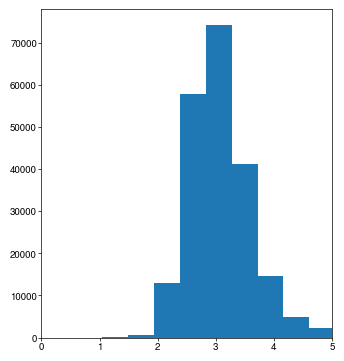

In [12]:
fig, axs = plotter.one_column_plot()

axs.hist(fits_df['chi_sqr'], 100);
plt.xlim([0, 5])
plt.show()

### Figure 2 — example puncta: raw / weights / fit / residual / spectrum

Rather than re-fitting, pick `N_PUNCTA` individual single-frame localisations directly
from the loaded fits, then re-render everything downstream straight from the raw data:
crop the actual raw frame each fit came from (a direct single-file read -- see this
notebook's intro on why no multi-file handling is needed here), recompute the
photoelectron conversion and fitting weights, and reconstruct the fitted PSF model from
the stored fit parameters (Gaussian + Bayer mask, using the stored `A_*`/`bg_*`
fractions de-normalised by `photons`/`background_photons` back to absolute units).

In [14]:
def read_frame(file_path, frame_idx, dtype=None):
    """Read ONE frame directly -- no multi-file group needed (see intro markdown)."""
    with tifffile.TiffFile(file_path, is_ome=False) as tf:
        page = tf.pages[frame_idx].asarray()
    return page.astype(dtype) if dtype else page


# ── Pick N_PUNCTA single-frame localisations that pass a basic quality filter ──
margin = ROI_SIZE / 2
valid_fits = fits_df[
    (fits_df['xc'] > margin) & (fits_df['xc'] < width - margin) &
    (fits_df['yc'] > margin) & (fits_df['yc'] < height - margin)
    & (fits_df['chi_sqr'] < CHI_SQR_MAX)
    & (fits_df['background_photons'] > PHOTON_BG_MIN) & (fits_df['background_photons'] < PHOTON_BG_MAX)
    & (fits_df['photons'] < MAX_PHOTONS_OVERVIEW) & (fits_df['photons'] > MIN_PHOTONS_OVERVIEW)
].reset_index(drop=True)
print(f'{len(valid_fits):,}/{len(fits_df):,} pass the quality filter and have a full '
      f'{ROI_SIZE}x{ROI_SIZE} ROI available')

masks_stacked = M_F.get_stacked_masks(0, 0, width, height, SupRes_F.mosaic_unit)
smoothing_function = types.SimpleNamespace(
    args={'sigma': 1.5}, extent=1.5, smoothing_function=sCMOS.gaussian_filter_stack, data_arg='image',
)

rng = np.random.default_rng(SELECTION_SEED)
chosen_rows = valid_fits.iloc[rng.choice(len(valid_fits), size=N_PUNCTA, replace=False)].reset_index(drop=True)

puncta_all, weights_all, masks_all, coords_all, rows_all = [], [], [], [], []
for _, row in chosen_rows.iterrows():
    xcentre, ycentre = int(round(row['xc'])), int(round(row['yc']))
    xmin, xmax, ymin, ymax = SupRes_F.helper.calculate_roi_bounds(xcentre, ycentre, ROI_SIZE, width, height)

    frame_raw = read_frame(FILE, int(row['frame']), dtype=np.float32)
    raw_roi = frame_raw[ymin:ymax, xmin:xmax]
    pe_roi = IO.convert_to_photoelectrons(
        raw_roi, gain_map=gain_c[ymin:ymax, xmin:xmax], offset_map=offset_c[ymin:ymax, xmin:xmax],
        rqe=rqe_c[ymin:ymax, xmin:xmax],
    )
    smoothed_roi = IO.apply_smoothing(pe_roi, smoothing_function, dtype='float32')
    weights_roi = IO.generate_weights(smoothed_roi, read_noise=readnoise_c[ymin:ymax, xmin:xmax], dtype='float32')
    mask_roi = masks_stacked[ymin:ymax, xmin:xmax, :]

    puncta_all.append(pe_roi)
    weights_all.append(weights_roi)
    masks_all.append(mask_roi)
    coords_all.append((xmin, ymin))
    rows_all.append(row)

99,005/212,360 pass the quality filter and have a full 12x12 ROI available


In [15]:
# ── Reconstruct the fitted PSF model + residual for each chosen punctum ────────
# Mask/h5 channel order is B, G, R (np.unique(mosaic_unit), alphabetical -- true
# regardless of ZWO's RGGB vs Ximea's BGGR physical layout, since get_stacked_masks
# was built from SupRes_F.mosaic_unit above). The h5's A_*/bg_* columns are normalised
# fractions (sum to 1); de-normalise back to absolute photon-like units using each
# row's own 'photons'/'background_photons' totals.
x_arr = np.arange(ROI_SIZE, dtype=np.float32)
models, residuals, spectra, xy_local, frame_labels = {}, {}, {}, {}, {}

for k, row in enumerate(rows_all):
    xmin, ymin = coords_all[k]
    xc_local, yc_local = row['xc'] - xmin, row['yc'] - ymin
    s_x, s_y = row['s_x'], row['s_y']

    A_frac = np.array([row['A_B'], row['A_G'], row['A_R']])
    bg_frac = np.array([row['bg_B'], row['bg_G'], row['bg_R']])
    A_abs = A_frac * row['photons']
    bg_abs = bg_frac * row['background_photons']

    gauss2d = np.zeros((ROI_SIZE, ROI_SIZE), dtype=np.float32)
    gauss2d = gaussoptfuncs.gaussian_unscaled_model(gauss2d, x_arr, ROI_SIZE, xc_local, yc_local, s_x, s_y)

    model = np.zeros((ROI_SIZE, ROI_SIZE), dtype=np.float32)
    mask_roi = masks_all[k]
    for c in range(3):
        m = mask_roi[:, :, c]
        model[m] = A_abs[c] * gauss2d[m] + bg_abs[c]

    models[k]       = model
    residuals[k]     = puncta_all[k] - model
    spectra[k]       = A_frac
    xy_local[k]      = (xc_local, yc_local)
    frame_labels[k]  = int(row['frame'])

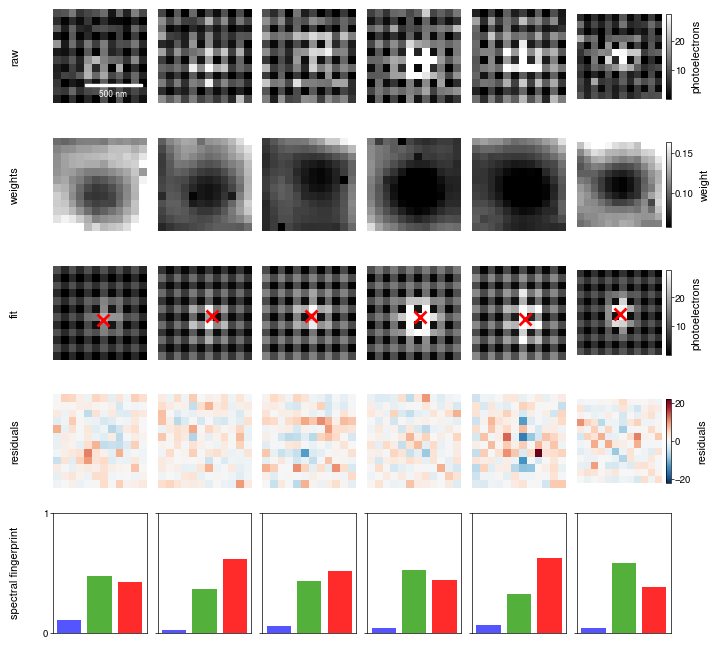

In [17]:
channel_colours = ["#5555ff", "#53b03b", "#ff2a2a"]  # B, G, R -- matches Ternary_Plot_SingleMolecules.ipynb
row_labels = ['raw', 'weights', 'fit', 'residuals', 'spectral fingerprint']

fig, axs = plotter.two_column_plot(nrows=5, ncols=N_PUNCTA, width=6.69, height=6.5)

vmin = np.percentile(puncta_all, 5)
vmax = np.percentile(puncta_all, 98)

vmin_weights = np.percentile(weights_all, 5)
vmax_weights = np.percentile(weights_all, 98)

rmaxes = np.zeros(N_PUNCTA)
for k in range(N_PUNCTA):
    rmaxes[k] = np.max(np.abs(residuals[k]))
rmax = np.max(rmaxes)

for k in range(N_PUNCTA):
    col = k
    raw_roi = puncta_all[k]
    xc_local, yc_local = xy_local[k]

    axs[0, col], _ = plotter.image_plot(
        axs[0, col], raw_roi, vmin=vmin, vmax=vmax, origin='upper',
        scalebar=(col == 0), scalebarsize=500.0, scalebarlabel='500 nm',
        colorbar=(col == 5), colorbar_label='photoelectrons'
    )

    axs[1, col], _ = plotter.image_plot(axs[1, col],
                                        weights_all[k], vmin=vmin_weights, vmax=vmax_weights, cmap='gray', origin='upper',
                                        colorbar=(col == 5), colorbar_label='weight'
                      )
    axs[1, col].set_xticks([]); axs[1, col].set_yticks([])

    axs[2, col], _ = plotter.image_plot(axs[2, col], models[k], vmin=vmin, vmax=vmax, origin='upper',
                                        colorbar=(col == 5), colorbar_label='photoelectrons')
    axs[2, col].plot(xc_local, yc_local, 'rx', markersize=8, markeredgewidth=2)

    axs[3, col], _ = plotter.image_plot(axs[3, col], residuals[k], cmap='RdBu_r', vmin=-rmax, vmax=rmax, origin='upper',
                                       colorbar=(col == 5), colorbar_label='residuals')
    axs[3, col].set_xticks([]); axs[3, col].set_yticks([])

    axs[4, col].bar(np.arange(3), spectra[k], color=channel_colours)
    axs[4, col].set_ylim([0, 1]); axs[4, col].set_xticks([]); axs[4, col].set_yticks([0, 1])
    if col != 0:
        axs[4, col].set_yticklabels('')
    axs[4, col].grid(False)


for row in range(5):
    axs[row, 0].text(-0.35, 0.5, row_labels[row], transform=axs[row, 0].transAxes,
                      fontsize=8, ha='right', va='center', rotation=90)

plotter.save_or_show(fig, save_path=str(FIGURE_DIR / f'example_puncta_raw_weights_fit_residual_spectrum_FRET_{POSITION}.svg'), show=True)